# I-JEPA - Visual Experiments

> **Goal:** Build intuition for the image-specific choices that make I-JEPA learn useful representations without reconstructing pixels.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Multi-block masking** | What information is exposed to the context and target branches? |
| 2 | **Encode, then select** | Why does the target encoder process the full image before target tokens are selected? |
| 3 | **Mask geometry trade-off** | How do target size and visible context change predictability? |
| 4 | **Position-conditioned prediction** | Why must one context representation be told which target block to predict? |

---
**Linked theory:** [research/07-i-jepa.md](../research/07-i-jepa.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
})

grid_size = 14
axis = np.linspace(-1, 1, grid_size)
xx, yy = np.meshgrid(axis, axis)

def semantic_field(seed=0):
    rng = np.random.default_rng(seed)
    field = 1.2 * np.exp(-((xx + 0.38) ** 2 + (yy + 0.22) ** 2) / 0.18)
    field -= 0.9 * np.exp(-((xx - 0.35) ** 2 + (yy - 0.30) ** 2) / 0.12)
    field += 0.35 * np.sin(2.3 * xx + 1.4 * yy)
    field += 0.04 * rng.normal(size=field.shape)
    return field

def rectangle_mask(row, col, height, width, size=grid_size):
    mask = np.zeros((size, size), dtype=bool)
    mask[row:row + height, col:col + width] = True
    return mask

---
## Experiment 1: Multi-block masking

**Question:** What does I-JEPA expose to each branch?

The target branch receives representations selected from several spatial blocks. The context branch sees one large block with every target overlap removed. This creates multiple prediction tasks from a shared context while preventing direct copying.

In [2]:
field_exp1 = semantic_field(seed=3)
target_specs_exp1 = [(1, 2, 4, 5), (2, 8, 5, 4), (8, 1, 4, 5), (8, 8, 4, 4)]
target_masks_exp1 = [rectangle_mask(*spec) for spec in target_specs_exp1]
target_union_exp1 = np.logical_or.reduce(target_masks_exp1)

context_box_exp1 = rectangle_mask(1, 1, 12, 12)
context_mask_exp1 = context_box_exp1 & ~target_union_exp1

target_labels_exp1 = np.zeros_like(field_exp1)
for index, mask in enumerate(target_masks_exp1, start=1):
    target_labels_exp1[mask] = index

visible_field_exp1 = np.where(context_mask_exp1, field_exp1, np.nan)

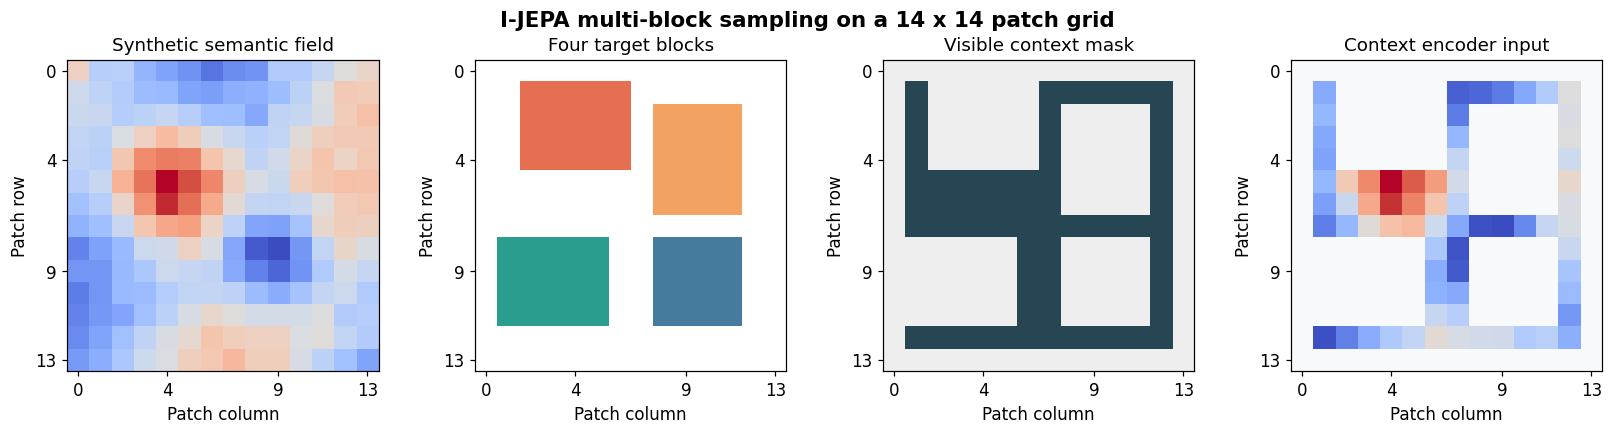

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
fig.suptitle('I-JEPA multi-block sampling on a 14 x 14 patch grid', fontsize=14, fontweight='bold')

images = [
    (field_exp1, 'Synthetic semantic field', 'coolwarm'),
    (target_labels_exp1, 'Four target blocks', ListedColormap(['white', '#e76f51', '#f4a261', '#2a9d8f', '#457b9d'])),
    (context_mask_exp1.astype(float), 'Visible context mask', ListedColormap(['#eeeeee', '#264653'])),
    (visible_field_exp1, 'Context encoder input', 'coolwarm'),
]

for ax, (image, title, cmap) in zip(axes, images):
    ax.imshow(image, cmap=cmap, interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Patch column')
    ax.set_ylabel('Patch row')
    ax.set_xticks([0, 4, 9, 13])
    ax.set_yticks([0, 4, 9, 13])

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Four target blocks cover distinct regions, while one large context block retains only patches outside their union.
2. **Why it looks this way:** Removing overlap denies the context encoder direct access to target content. Reusing the context for several blocks makes each image provide multiple learning signals.
3. **Key takeaway:** I-JEPA masking is structured information control, not random token deletion.

---
## Experiment 2: Encode the full image, then select targets

**Question:** Why does the target encoder process the unmasked image before target tokens are selected?

A contextual encoder mixes local and global evidence. Masking first changes that evidence and therefore changes the target itself. The full-image target branch instead defines a stable representation and selects only the requested positions afterward.

In [4]:
def contextual_encode(values, valid):
    safe_values = np.where(valid, values, 0.0)
    row_count = np.maximum(valid.sum(axis=1, keepdims=True), 1)
    col_count = np.maximum(valid.sum(axis=0, keepdims=True), 1)
    row_mean = (safe_values.sum(axis=1, keepdims=True) / row_count) * np.ones_like(values)
    col_mean = (safe_values.sum(axis=0, keepdims=True) / col_count) * np.ones_like(values)

    padded_values = np.pad(safe_values, 1)
    padded_valid = np.pad(valid.astype(float), 1)
    local_sum = np.zeros_like(values)
    local_count = np.zeros_like(values)
    for row_shift in range(3):
        for col_shift in range(3):
            local_sum += padded_values[row_shift:row_shift + grid_size, col_shift:col_shift + grid_size]
            local_count += padded_valid[row_shift:row_shift + grid_size, col_shift:col_shift + grid_size]
    local_mean = local_sum / np.maximum(local_count, 1)
    global_mean = safe_values.sum() / max(valid.sum(), 1)
    return 0.45 * safe_values + 0.20 * local_mean + 0.15 * row_mean + 0.15 * col_mean + 0.05 * global_mean

field_exp2 = semantic_field(seed=8)
target_exp2 = rectangle_mask(4, 5, 5, 5)
full_valid_exp2 = np.ones_like(target_exp2)
masked_valid_exp2 = ~target_exp2

encode_then_select_exp2 = contextual_encode(field_exp2, full_valid_exp2)
mask_then_encode_exp2 = contextual_encode(field_exp2, masked_valid_exp2)
difference_exp2 = np.abs(encode_then_select_exp2 - mask_then_encode_exp2)
target_difference_exp2 = difference_exp2[target_exp2].mean()

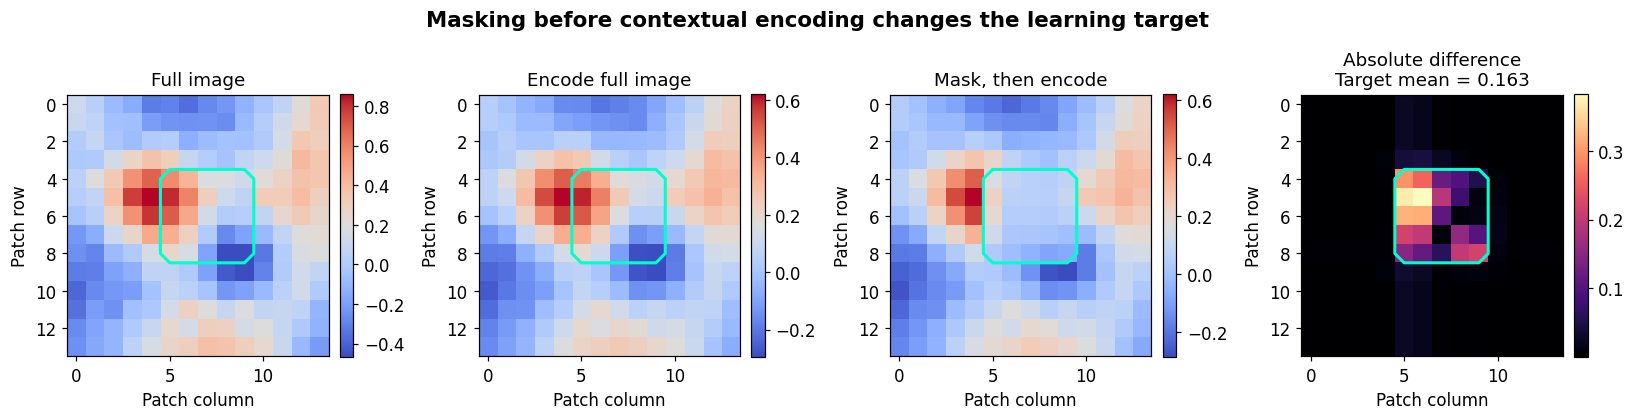

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
fig.suptitle('Masking before contextual encoding changes the learning target', fontsize=14, fontweight='bold')

panels = [
    (field_exp2, 'Full image', 'coolwarm'),
    (encode_then_select_exp2, 'Encode full image', 'coolwarm'),
    (mask_then_encode_exp2, 'Mask, then encode', 'coolwarm'),
    (difference_exp2, f'Absolute difference\nTarget mean = {target_difference_exp2:.3f}', 'magma'),
]

for ax, (image, title, cmap) in zip(axes, panels):
    rendered = ax.imshow(image, cmap=cmap, interpolation='nearest')
    ax.contour(target_exp2.astype(float), levels=[0.5], colors=['#00ffcc'], linewidths=2)
    ax.set_title(title)
    ax.set_xlabel('Patch column')
    ax.set_ylabel('Patch row')
    fig.colorbar(rendered, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Representations inside and around the cyan target boundary differ when the region is removed before contextual encoding.
2. **Why it looks this way:** Local, row, column, and global summaries all depend on which patches are present. Mask-first encoding therefore defines a different target distribution.
3. **Key takeaway:** Encode-then-select gives the predictor a target produced with complete image context while still restricting which target tokens enter the loss.

---
## Experiment 3: Target scale and context informativeness

**Question:** How do target size and visible context jointly affect predictability?

We generate smooth latent fields, hide a centered square, and fit a linear predictor from visible patches to the target mean. This is not an I-JEPA training replica; it isolates the information trade-off controlled by mask geometry.

In [6]:
rng_exp3 = np.random.default_rng(13)
sample_count_exp3 = 420
basis_exp3 = np.stack([
    np.ones_like(xx), xx, yy, xx * yy,
    np.sin(np.pi * xx), np.cos(np.pi * yy),
    np.sin(np.pi * (xx + yy)), np.cos(2 * np.pi * xx - np.pi * yy),
], axis=0)
coefficients_exp3 = rng_exp3.normal(size=(sample_count_exp3, len(basis_exp3)))
fields_exp3 = np.einsum('sb,bhw->shw', coefficients_exp3, basis_exp3)
fields_exp3 += 0.12 * rng_exp3.normal(size=fields_exp3.shape)

target_sizes_exp3 = [2, 3, 4, 5, 6]
context_fractions_exp3 = [0.25, 0.45, 0.65, 0.85]
nmse_exp3 = np.zeros((len(target_sizes_exp3), len(context_fractions_exp3)))

train_count_exp3 = 300
for size_index, target_size in enumerate(target_sizes_exp3):
    start = (grid_size - target_size) // 2
    target_mask = rectangle_mask(start, start, target_size, target_size)
    candidate_indices = np.flatnonzero(~target_mask.ravel())
    targets = fields_exp3[:, target_mask].mean(axis=1)

    for fraction_index, fraction in enumerate(context_fractions_exp3):
        visible_count = int(round(fraction * len(candidate_indices)))
        local_rng = np.random.default_rng(1000 + 10 * size_index + fraction_index)
        visible_indices = local_rng.choice(candidate_indices, size=visible_count, replace=False)
        features = fields_exp3.reshape(sample_count_exp3, -1)[:, visible_indices]

        x_train = features[:train_count_exp3]
        y_train = targets[:train_count_exp3]
        x_test = features[train_count_exp3:]
        y_test = targets[train_count_exp3:]
        x_mean = x_train.mean(axis=0)
        y_mean = y_train.mean()
        x_scale = x_train.std(axis=0) + 1e-6
        x_train_scaled = (x_train - x_mean) / x_scale
        x_test_scaled = (x_test - x_mean) / x_scale
        ridge = 0.3
        gram = x_train_scaled @ x_train_scaled.T + ridge * np.eye(train_count_exp3)
        dual_weights = np.linalg.solve(gram, y_train - y_mean)
        predictions = y_mean + x_test_scaled @ x_train_scaled.T @ dual_weights
        nmse_exp3[size_index, fraction_index] = np.mean((predictions - y_test) ** 2) / np.var(y_test)

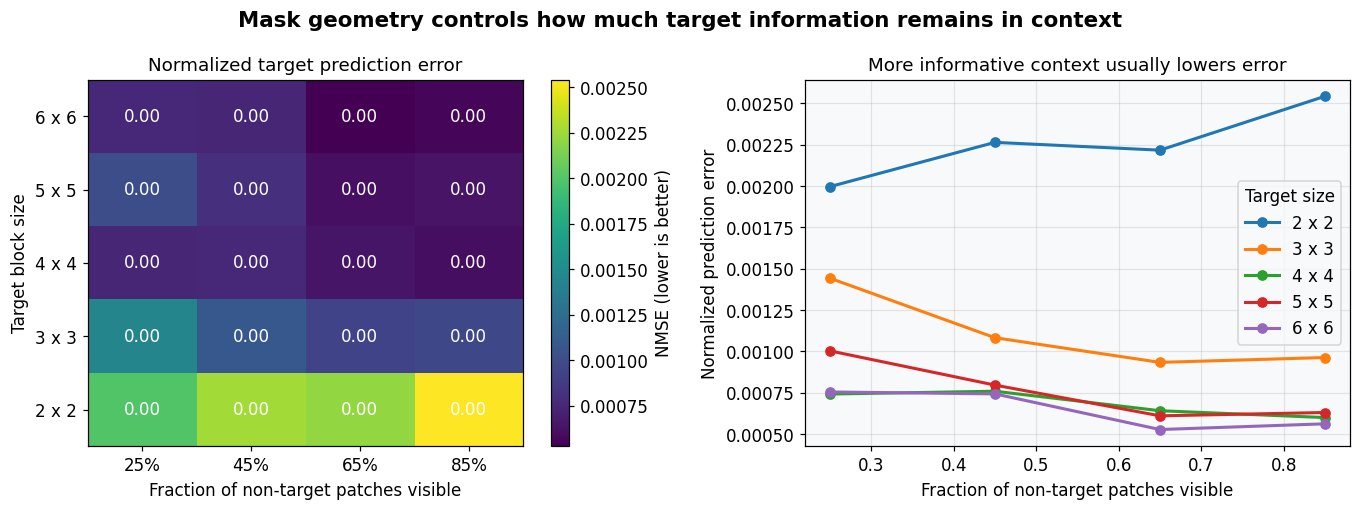

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))
fig.suptitle('Mask geometry controls how much target information remains in context', fontsize=14, fontweight='bold')

ax = axes[0]
image = ax.imshow(nmse_exp3, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(len(context_fractions_exp3)), [f'{fraction:.0%}' for fraction in context_fractions_exp3])
ax.set_yticks(range(len(target_sizes_exp3)), [f'{size} x {size}' for size in target_sizes_exp3])
ax.set_xlabel('Fraction of non-target patches visible')
ax.set_ylabel('Target block size')
ax.set_title('Normalized target prediction error')
for row in range(nmse_exp3.shape[0]):
    for col in range(nmse_exp3.shape[1]):
        ax.text(col, row, f'{nmse_exp3[row, col]:.2f}', ha='center', va='center', color='white')
fig.colorbar(image, ax=ax, label='NMSE (lower is better)')

ax = axes[1]
for size_index, target_size in enumerate(target_sizes_exp3):
    ax.plot(context_fractions_exp3, nmse_exp3[size_index], marker='o', linewidth=2, label=f'{target_size} x {target_size}')
ax.set_xlabel('Fraction of non-target patches visible')
ax.set_ylabel('Normalized prediction error')
ax.set_title('More informative context usually lowers error')
ax.grid(alpha=0.3)
ax.legend(title='Target size')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Prediction error changes across both target scale and visible-context fraction rather than being determined by mask ratio alone.
2. **Why it looks this way:** Larger context exposes more evidence about the smooth field, while target scale changes which spatial statistics must be inferred.
3. **Key takeaway:** I-JEPA's block scales are learning-task hyperparameters: they decide whether prediction is trivial, impossible, or semantically useful.

---
## Experiment 4: Position-conditioned prediction

**Question:** Why are positional mask tokens supplied to the predictor?

The same visible context is reused for several targets. A predictor without target position can emit only one generic answer. Position features let it query a different part of the inferred latent field for each requested block.

In [8]:
field_exp4 = semantic_field(seed=21)
targets_exp4 = [rectangle_mask(2, 2, 4, 4), rectangle_mask(8, 8, 4, 4)]
target_union_exp4 = np.logical_or.reduce(targets_exp4)
context_exp4 = ~target_union_exp4

position_basis_exp4 = np.stack([
    np.ones_like(xx), xx, yy, xx * yy,
    np.sin(np.pi * xx), np.cos(np.pi * yy),
    np.sin(np.pi * (xx + yy)), np.cos(2 * np.pi * xx - np.pi * yy),
], axis=-1)
design_exp4 = position_basis_exp4[context_exp4]
observations_exp4 = field_exp4[context_exp4]
coefficients_exp4 = np.linalg.solve(
    design_exp4.T @ design_exp4 + 0.05 * np.eye(design_exp4.shape[1]),
    design_exp4.T @ observations_exp4,
)

positioned_field_exp4 = position_basis_exp4 @ coefficients_exp4
generic_value_exp4 = observations_exp4.mean()
generic_prediction_exp4 = np.full_like(field_exp4, np.nan)
positioned_prediction_exp4 = np.full_like(field_exp4, np.nan)
generic_prediction_exp4[target_union_exp4] = generic_value_exp4
positioned_prediction_exp4[target_union_exp4] = positioned_field_exp4[target_union_exp4]

generic_mse_exp4 = np.mean((generic_prediction_exp4[target_union_exp4] - field_exp4[target_union_exp4]) ** 2)
positioned_mse_exp4 = np.mean((positioned_prediction_exp4[target_union_exp4] - field_exp4[target_union_exp4]) ** 2)

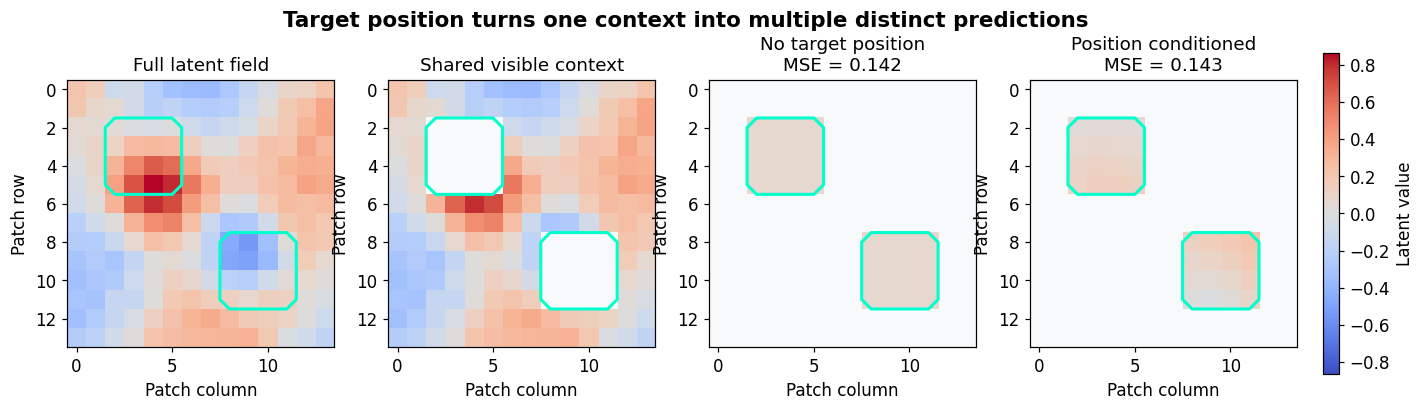

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
fig.suptitle('Target position turns one context into multiple distinct predictions', fontsize=14, fontweight='bold')

context_view_exp4 = np.where(context_exp4, field_exp4, np.nan)
panels = [
    (field_exp4, 'Full latent field'),
    (context_view_exp4, 'Shared visible context'),
    (generic_prediction_exp4, f'No target position\nMSE = {generic_mse_exp4:.3f}'),
    (positioned_prediction_exp4, f'Position conditioned\nMSE = {positioned_mse_exp4:.3f}'),
]

value_limit_exp4 = np.max(np.abs(field_exp4))
for ax, (image, title) in zip(axes, panels):
    rendered = ax.imshow(image, cmap='coolwarm', vmin=-value_limit_exp4, vmax=value_limit_exp4, interpolation='nearest')
    ax.contour(target_union_exp4.astype(float), levels=[0.5], colors=['#00ffcc'], linewidths=2)
    ax.set_title(title)
    ax.set_xlabel('Patch column')
    ax.set_ylabel('Patch row')
fig.colorbar(rendered, ax=axes, fraction=0.018, pad=0.02, label='Latent value')

plt.show()

### What you see

1. **What the plot shows:** The unconditioned predictor fills both targets with one context average, while the position-conditioned predictor produces different values at different coordinates.
2. **Why it looks this way:** Position features specify which spatial query the shared context representation must answer.
3. **Key takeaway:** Positional mask tokens are part of the prediction condition; without them, multiple target blocks are ambiguous.

---
## Summary / Key Takeaways

| Experiment | Key insight |
|---|---|
| 1. Multi-block masking | Structured blocks create several non-copying prediction tasks from one image. |
| 2. Encode, then select | Full-image encoding defines contextualized and stable target representations. |
| 3. Mask geometry trade-off | Target scale and context coverage control task difficulty and information content. |
| 4. Position-conditioned prediction | Positional tokens tell the predictor which target the shared context must explain. |

### Connection to the broader theory

I-JEPA turns the general JEPA contract into an image learning system through spatial multi-block masks, a full-image EMA target encoder, and a lightweight position-conditioned predictor. The objective remains latent prediction: no pixel decoder is needed.